In [141]:
import re

def query_to_tag(query: str) -> str:
    parts = re.findall(r'(\w+)\s*==\s*([\w.]+)', query)
    if not parts:
        return ""

    key_map = {
        "s": "xi",
        "burstiness": "b",
    }

    out = []
    for k, v in parts:
        out.append(f"{key_map.get(k, k)}={v}")

    return "_".join(out)


In [142]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [ ]:
mpl.rcdefaults()
#* SMALLER SIZE
# plt.rc('font', size=12)          # controls default text sizes
# plt.rc('axes', titlesize=14)     # fontsize of the axes title
# plt.rc('axes', labelsize=12)     # fontsize of the x and y labels
# plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
# plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
# plt.rc('legend', fontsize=12)    # legend fontsize
# plt.rc('figure', titlesize=14)   # fontsize of the figure title

#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=22)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels
plt.rc('legend', fontsize=22)    # legend fontsize
plt.rc('figure', titlesize=14)   # fontsize of the figure title


In [144]:
from pathlib import Path

In [145]:
BATCH = "008"
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/new").expanduser()


In [179]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))


SINGLE SIMULATION (SELECT COUPLE s and burstiness)

In [206]:
burstiness =0.75
spending_noise = 5
QUERY = f"s == {spending_noise} and burstiness == {burstiness}"

In [207]:
simu_id = metadata.query(QUERY).iloc[0].simulation_id
meta_row = metadata.query(QUERY).iloc[0]

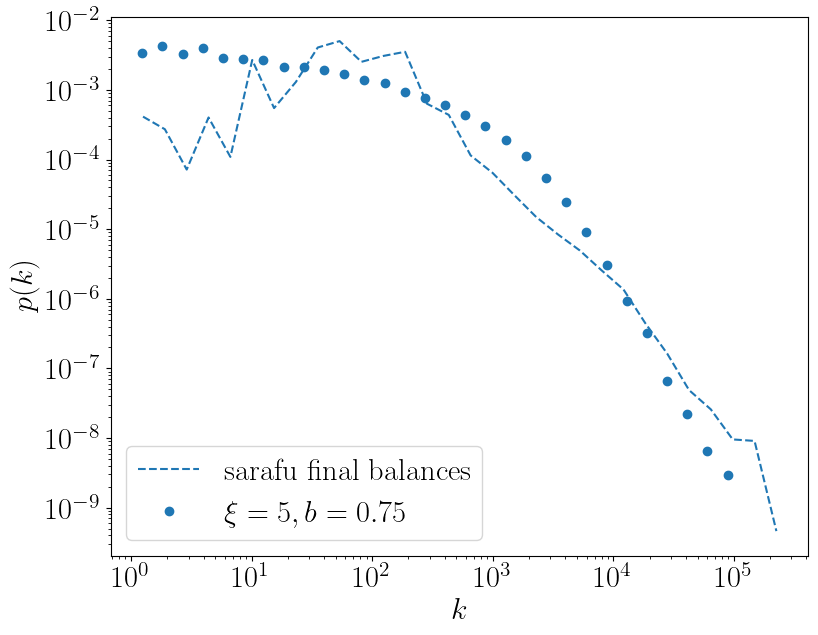

In [208]:
keyword = "final_balances"

# metadata
s = meta_row["s"]
b = meta_row["burstiness"]

# filenames (standard)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"

# load
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", label="sarafu final balances", color="tab:blue")
ax.plot(h2[0], h2[1], "o",  label=rf"$\xi={s}, b={b}$",  color="tab:blue")

ax.set_xlabel("$k$")
ax.set_ylabel("$p(k)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

# save figure with same stem
fig.savefig(FIGURES / f"{fname_simu}.pdf")


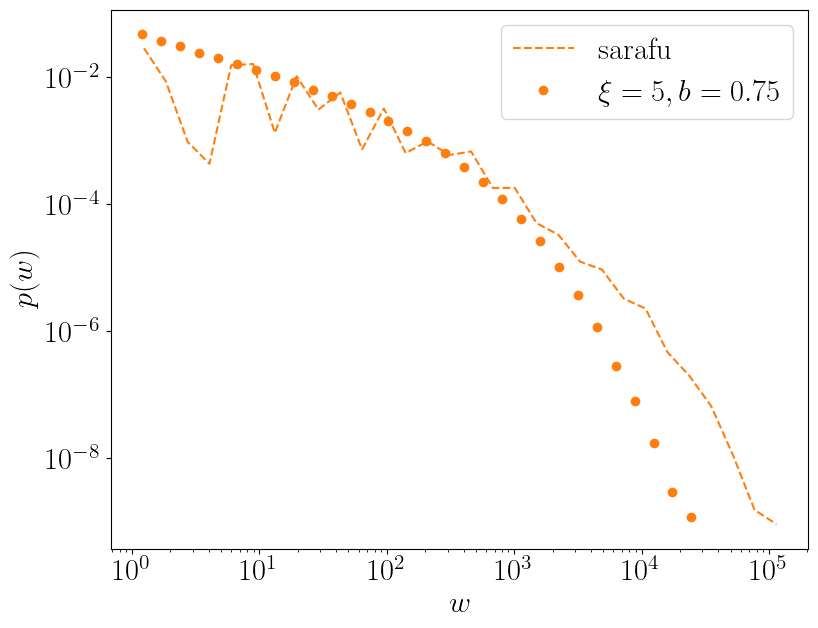

In [209]:
keyword = "transaction_size"

# metadata
s = meta_row["s"]
b = meta_row["burstiness"]

# filenames (standard)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"

# load
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", label="sarafu", color="tab:orange")
ax.plot(h2[0], h2[1], "o",  label=rf"$\xi={s}, b={b}$", color="tab:orange")

ax.set_xlabel("$w$")
ax.set_ylabel("$p(w)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

# save figure with same stem
fig.savefig(FIGURES / f"{fname_simu}.pdf")


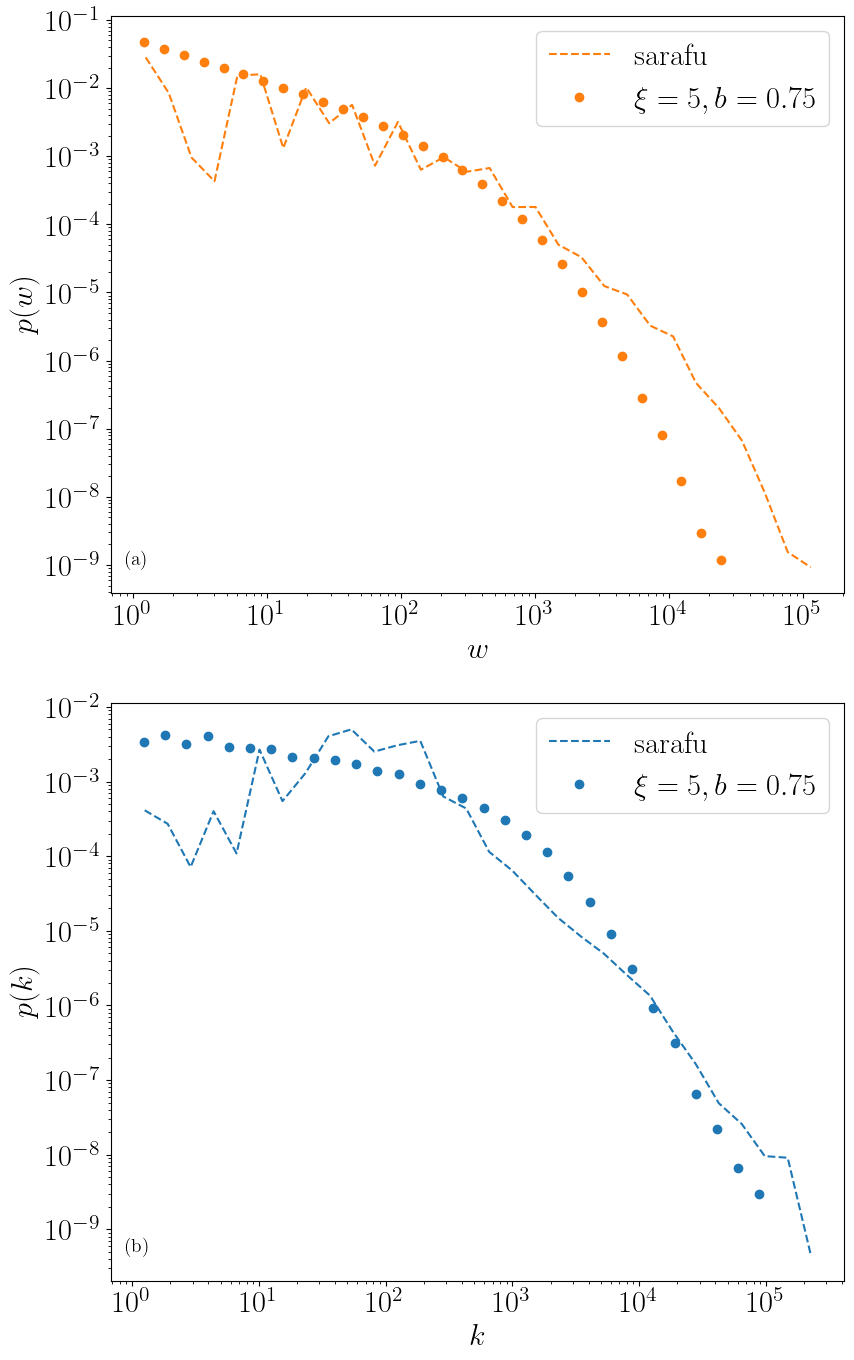

In [210]:
keyword1 = "transaction_size"
keyword2 = "final_balances"


# filenames (standard)
fname_ts_sarafu = f"sarafu__metric={keyword1}__s=NA__b=NA"
fname_ts_simu   = f"simulation__metric={keyword1}__s={s}__b={b}"

fname_fb_sarafu = f"sarafu__metric={keyword2}__s=NA__b=NA"
fname_fb_simu   = f"simulation__metric={keyword2}__s={s}__b={b}"

# load histograms
h1_ts = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_ts_sarafu}.pkl", "rb"))
h2_ts = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_ts_simu}.pkl", "rb"))

h1_fb = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_fb_sarafu}.pkl", "rb"))
h2_fb = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_fb_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(2, 1, figsize=(9, 14))

# --- transaction size ---
ax[0].plot(h1_ts[0], h1_ts[1], "--", color="tab:orange", label="sarafu")
ax[0].plot(h2_ts[0], h2_ts[1], "o",  color="tab:orange", label=rf"$\xi={s}, b={b}$")
ax[0].set_xlabel("$w$")
ax[0].set_ylabel("$p(w)$")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].legend()

# --- final balances ---
ax[1].plot(h1_fb[0], h1_fb[1], "--", color="tab:blue", label="sarafu")
ax[1].plot(h2_fb[0], h2_fb[1], "o",  color="tab:blue", label=rf"$\xi={s}, b={b}$")
ax[1].set_xlabel("$k$")
ax[1].set_ylabel("$p(k)$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend()

# panel labels
ax[0].text(0.02, 0.05, "(a)", transform=ax[0].transAxes, fontsize=14)
ax[1].text(0.02, 0.05, "(b)", transform=ax[1].transAxes, fontsize=14)

fig.tight_layout()

# save figure with metadata encoded
fig.savefig(FIGURES / f"comparison__metrics=transaction_size+final_balances__s={s}__b={b}.pdf")


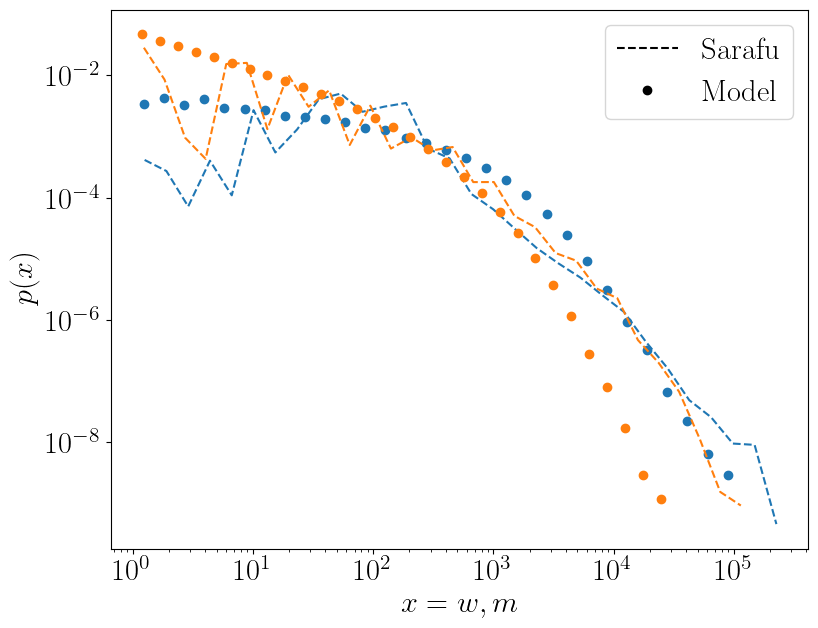

In [211]:
from matplotlib.lines import Line2D

# keywords
kw_fb = "final_balances"
kw_ts = "transaction_size"

# filenames (standard)
fname_fb_sarafu = f"sarafu__metric={kw_fb}__s=NA__b=NA"
fname_fb_simu   = f"simulation__metric={kw_fb}__s={s}__b={b}"

fname_ts_sarafu = f"sarafu__metric={kw_ts}__s=NA__b=NA"
fname_ts_simu   = f"simulation__metric={kw_ts}__s={s}__b={b}"

# load histograms
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_fb_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_fb_simu}.pkl", "rb"))

h3 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_ts_sarafu}.pkl", "rb"))
h4 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_ts_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", color="tab:blue")
ax.plot(h2[0], h2[1], "o",  color="tab:blue")

ax.plot(h3[0], h3[1], "--", color="tab:orange")
ax.plot(h4[0], h4[1], "o",  color="tab:orange")

ax.set_xlabel("$x = w, m$")
ax.set_ylabel("$p(x)$")
ax.set_xscale("log")
ax.set_yscale("log")

# label_model=rf"Model: $\xi={s}, b={b}$"
label_model=rf"Model"

# custom legend
legend_elements = [
    Line2D([0], [0], linestyle="--", color="black", label="Sarafu"),
    Line2D([0], [0], linestyle="None", marker="o", color="black",
           label=label_model),
    # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
    # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
]

ax.legend(handles=legend_elements)

# save
fig.savefig(
    FIGURES / f"overlap__metrics=final_balances+transaction_size__s={s}__b={b}.pdf"
)


VARYING THE SIMULATION (SELECT JUST burstiness or s)

In [212]:
QUERY = f"burstiness == {burstiness}"
meta_slice = metadata.query(QUERY)
meta_slice = meta_slice.query("s not in [20,100]")
tag=query_to_tag(QUERY)


# meta_slice

In [213]:
tag

'b=0.75'

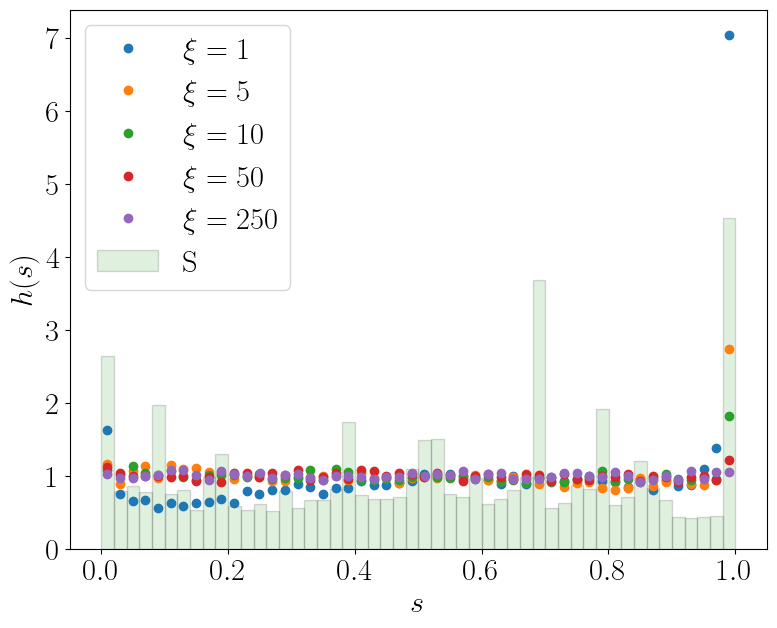

In [214]:

keyword = "spending_parameters"

# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# sarafu as bars (expects h1 = (centers, heights, widths))
ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:green", label="S")

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o',linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$h(s)$")
ax.legend()

# optional save (encodes the filter used + metric)
fig.savefig(FIGURES / f"comparison__metric={keyword}__filter={tag}.pdf")


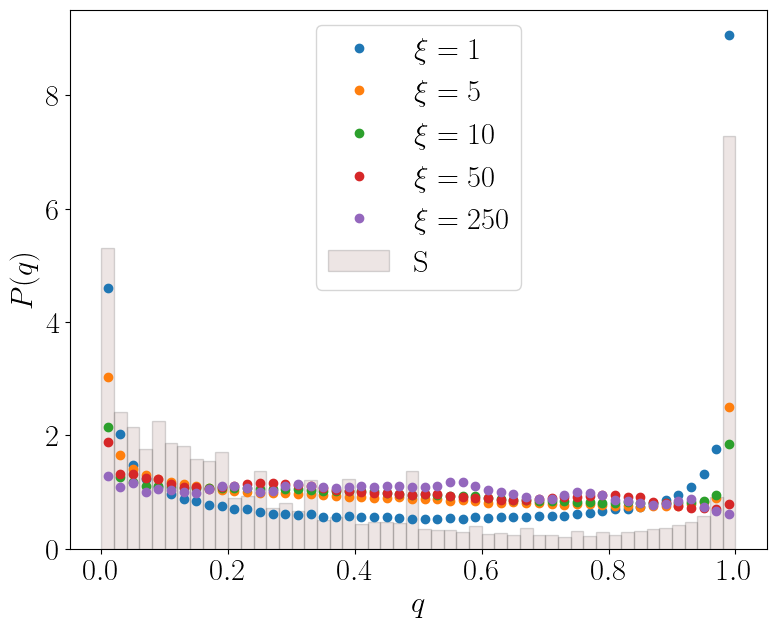

In [215]:

keyword = "spending_fraction"

# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# sarafu as bars (expects h1 = (centers, heights, widths))
ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:brown", label="S")

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o',linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(r"$q$")
ax.set_ylabel(r"$P(q)$")

ax.legend()

# optional save (encodes the filter used + metric)
fig.savefig(FIGURES / f"comparison__metric={keyword}__filter={tag}.pdf")


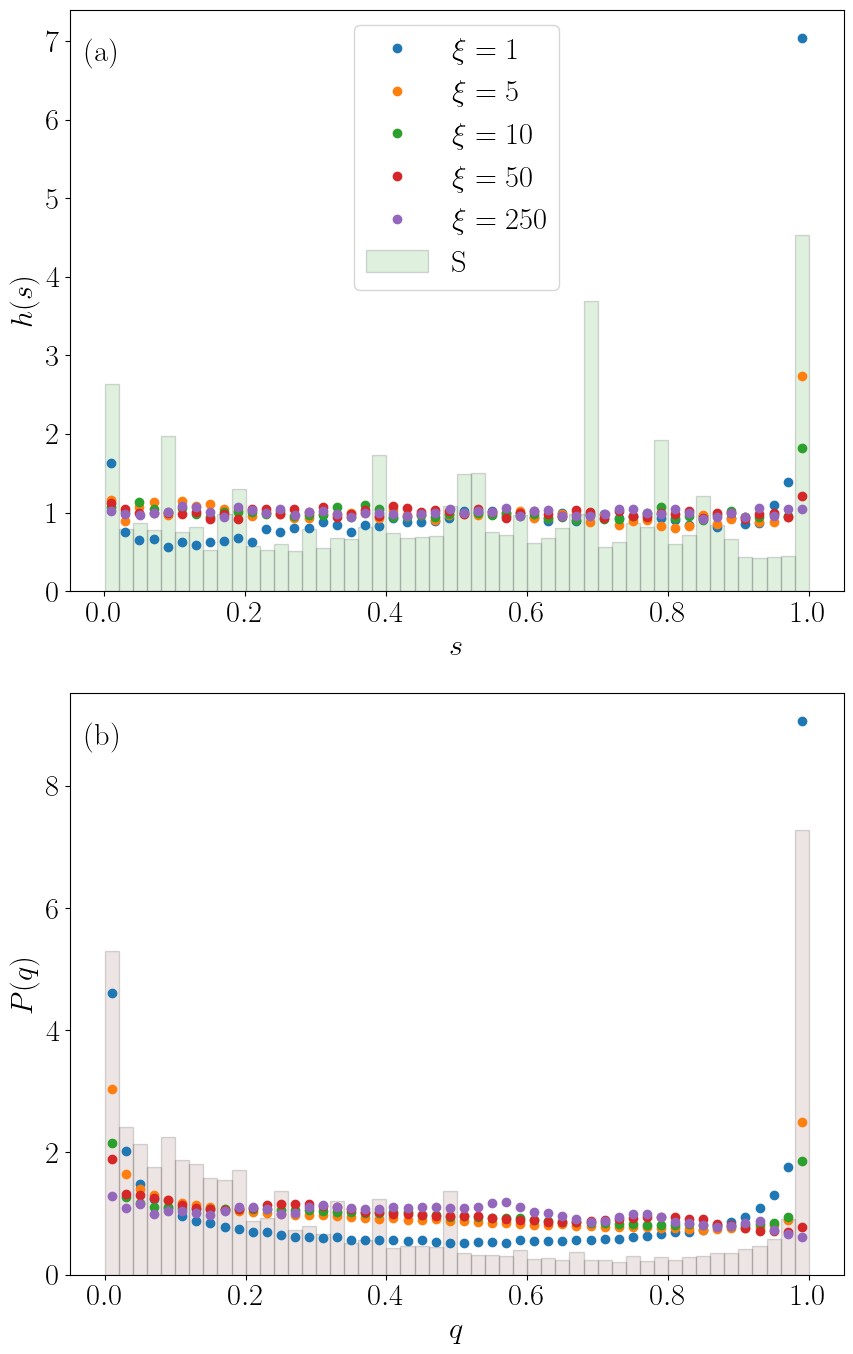

In [216]:
fig, ax = plt.subplots(2, 1, figsize=(9, 14), sharex=False)

# =======================
# (a) spending_parameters
# =======================
keyword1 = "spending_parameters"

fname_sarafu = f"sarafu__metric={keyword1}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

ax[0].bar(
    h1[0], h1[1], h1[2],
    align="center", edgecolor="k",
    alpha=0.15, color="tab:green",
    label="S"
)

for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword1}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    ax[0].plot(h_simu[0], h_simu[1], "o", linestyle="None", label=rf"$\xi={s}$")


ax[0].set_ylabel(r"$h(s)$")
ax[0].set_xlabel(r"$s$")
ax[0].legend()
ax[0].text(0.02, 0.95, "(a)", transform=ax[0].transAxes, va="top")


# ===================
# (b) spending_fraction
# ===================
keyword2 = "spending_fraction"

fname_sarafu = f"sarafu__metric={keyword2}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

ax[1].bar(
    h1[0], h1[1], h1[2],
    align="center", edgecolor="k",
    alpha=0.15, color="tab:brown",
    label="sarafu"
)

for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword2}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    ax[1].plot(h_simu[0], h_simu[1], "o", linestyle="None", label=rf"$\xi={s}$")

ax[1].set_xlabel(r"$q$")
ax[1].set_ylabel(r"$P(q)$")
# ax[1].legend()
ax[1].text(0.02, 0.95, "(b)", transform=ax[1].transAxes, va="top")


fig.tight_layout()
fig.savefig(
    FIGURES / f"comparison__metrics={keyword1}+{keyword2}__filter={tag}.pdf"
)
